Filename: /home/m/Documents/science_codes/Data/Coma_Chandra/filtered_subtracted_flux.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     186   (1352, 1315)   float64   
None
Filename: /home/m/Documents/science_codes/Data/Coma_Chandra/subtracted_flux.img
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     168   (1352, 1315)   float64   
None
Filename: /home/m/Documents/science_codes/Data/Coma_Chandra/filtered_thresh.expmap
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     337   (1352, 1315)   float32   
None


[]

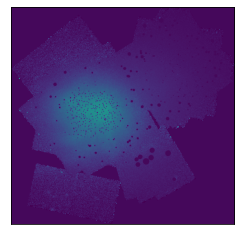

In [1]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments, scale_filter
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

from astropy.io import fits
from regions import Regions
import pyregion

D = 2

# N = 10000
# L = 5.*np.pi

# N_f = 4*N
# L_f = 4*L

# grid_dims = [N for _ in range(D)]
# grid_dims_f = [N_f for _ in range(D)]

# phys_dims = [L for _ in range(D)]
# phys_dims_f = [L_f for _ in range(D)]

# twopi = 2.*np.pi

# dk_f = twopi/L_f
# dk = twopi/L

# dx_f = L_f/N_f
# dx = L/N

# BREAK = 100 * dk_f


DATA_DIR = '/home/m/Documents/science_codes/Data/'
XRAY_DATA = DATA_DIR + 'Coma_Chandra/'

fsf = fits.open(XRAY_DATA + 'filtered_subtracted_flux.fits')
sf = fits.open(XRAY_DATA + 'subtracted_flux.img')
et = fits.open(XRAY_DATA + 'filtered_thresh.expmap')

#reg = Regions.read(XRAY_DATA + 'ds9.reg', format='ds9')
reg = pyregion.open(XRAY_DATA + 'ds9.reg').as_imagecoord(header=fsf[0].header)
filter = reg.get_filter()

mask = reg.get_mask(hdu=fsf[0])

print(fsf.info())
print(sf.info())
print(et.info())

plt.imshow(fsf[0].data, origin='lower', vmin=-9.820370487029719e-09, vmax=4.506728547715614e-07)
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

[]

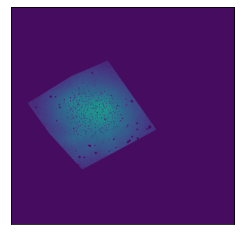

In [2]:
core = fsf[0].data * mask
et_core = et[0].data * mask
plt.imshow(core, origin='lower')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

[]

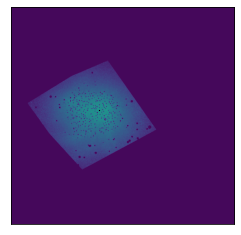

In [3]:
core_center = np.where(core == np.max(core))
#core[691,532] = 1e-6
plt.imshow(core, origin='lower', vmin=-9.820370487029719e-09, vmax=4.506728547715614e-07, cmap='viridis')
plt.scatter(532, 691, s=0.1, c='black', marker='x')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

[]

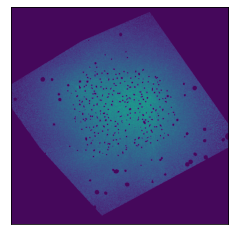

In [4]:
core2_left = (137,737)
core2_right = (840,568)
#core2_up = (572,961)
#core2_down = (428,346)
core2_up = (572,961+44)
core2_down = (428,346-44)
core2 = core[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
plt.imshow(core2, origin='lower', vmin=-9.820370487029719e-09, vmax=4.506728547715614e-07, cmap='viridis')
#plt.scatter(532, 691, s=0.1, c='black', marker='x')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

In [5]:
#beta = 0.6
# rc = 245 kpc
def beta_model(shape, I0, c, rc, beta):
    grid = np.indices(shape)
    r = np.linalg.norm([grid[i,...] - c[i] for i in range(len(shape))], axis=0)
    return I0 / (1. + (r/rc)**2)**(3.*beta - 0.5)

-1.4975073676618683e-07 3.0375488793912914e-07
-3.0375488793912914e-07 3.0375488793912914e-07


[]

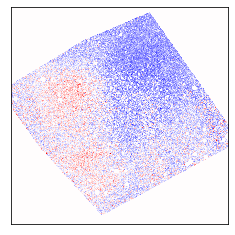

In [6]:

et_core2 = et_core[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
combined = core2#*et_core2

c = (691, 532)
shape = (1352,1352)
I0 = core[c]*1.1
model = beta_model(shape, I0, c, 200, 0.5)
fluct = combined - model[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
fluct[et_core2 == 0.] = 0.

pmin = - np.max([np.abs(np.max(fluct)), np.abs(np.min(fluct))])
pmax = np.max([np.abs(np.max(fluct)), np.abs(np.min(fluct))])

print(np.min(fluct), np.max(fluct))
print(pmin, pmax)

plt.imshow(fluct, origin='lower', vmin=pmin, vmax=pmax, cmap='seismic', interpolation='none')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

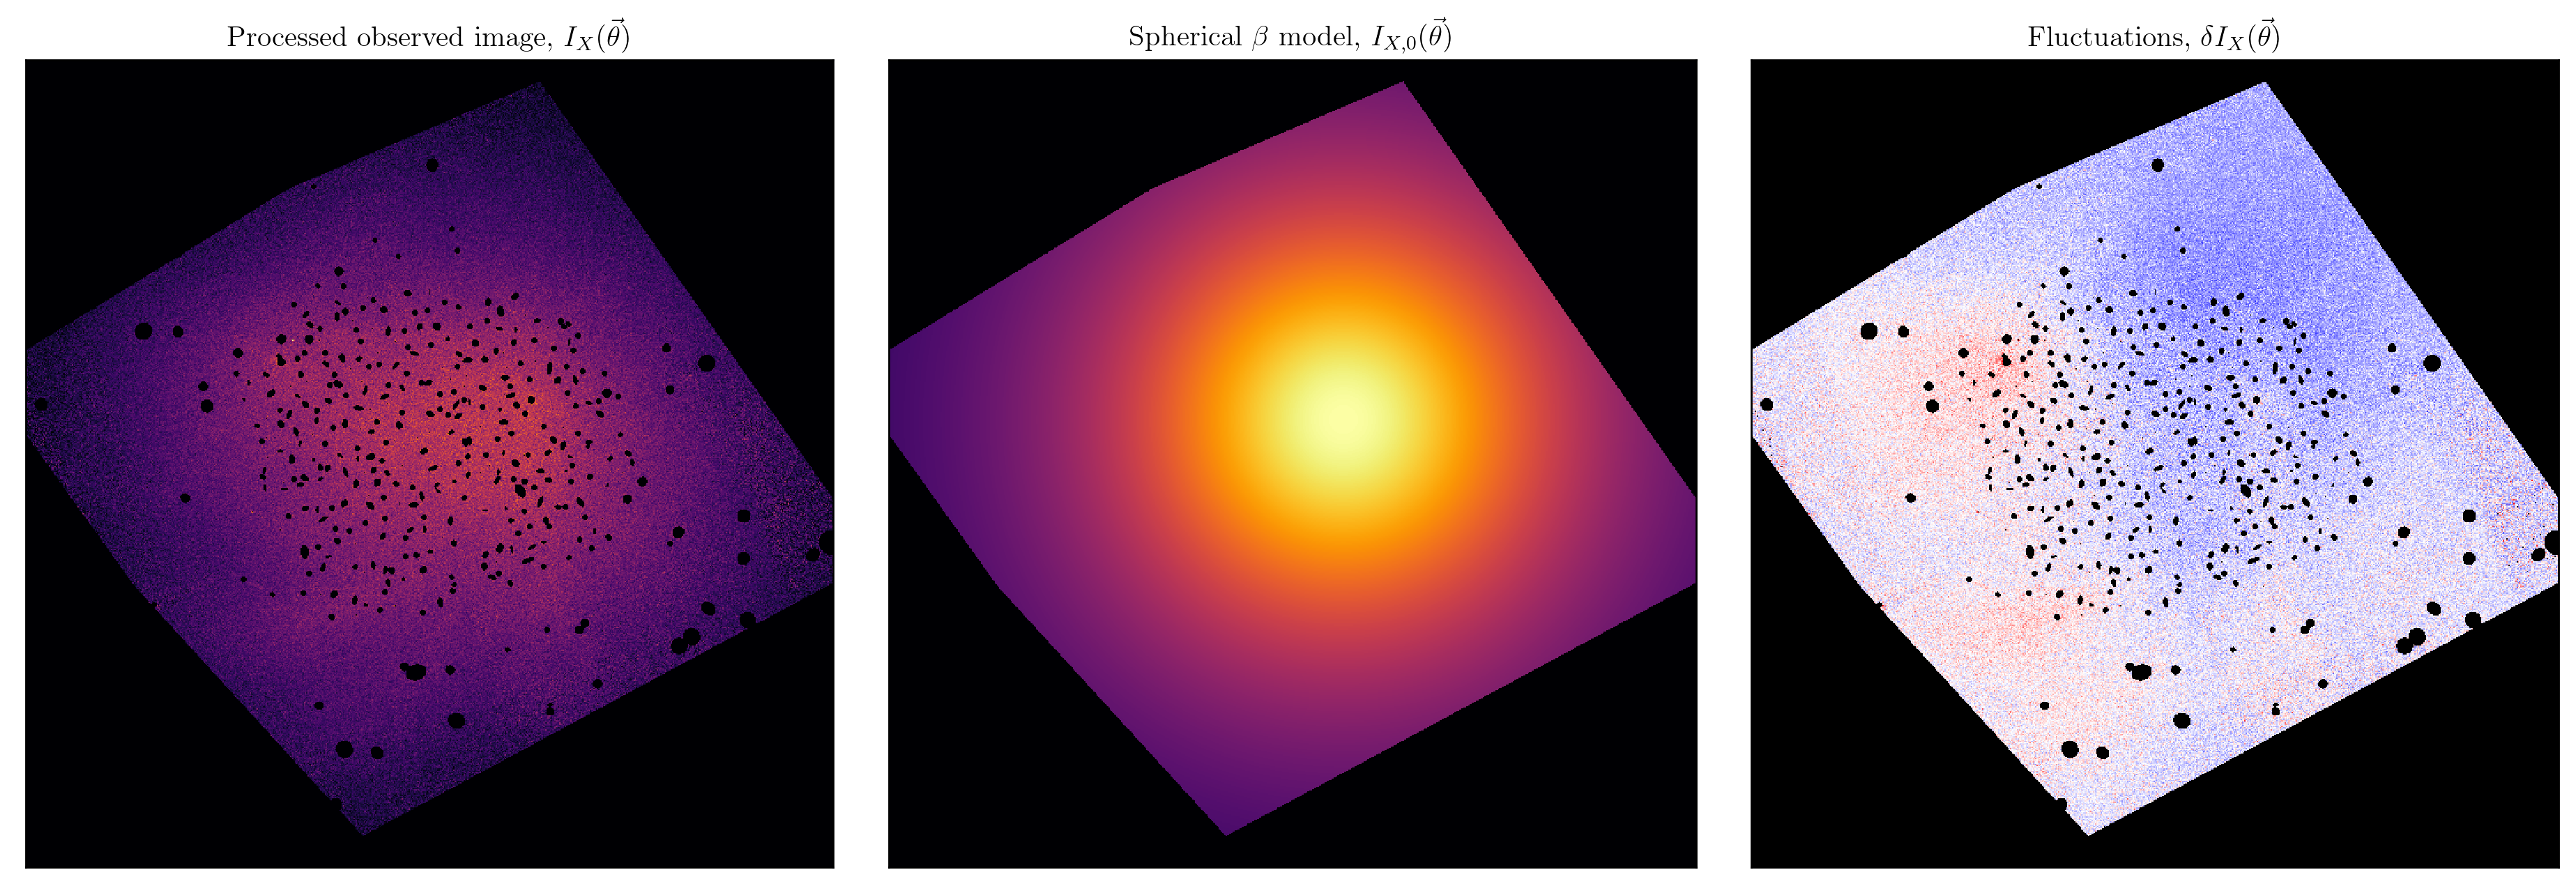

In [7]:

fig, ax = plt.subplots(1, 3, dpi=250, figsize=(15, 5))
#-9.820370487029719e-09
#ax[0].imshow(combined, origin='lower', vmin=np.min(combined), vmax=4.506728547715614e-07, interpolation='none', cmap='inferno')
#plotting.imshow_cbar(combined, fig, ax[0], {'origin': 'lower', 'vmin': 0., 'vmax': 4.506728547715614e-07, 'interpolation': 'none', 'cmap': 'inferno'})
ax[0].imshow(combined, origin='lower', vmin=0., vmax=4.506728547715614e-07, interpolation='none', cmap='inferno')

modelimage = model[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]*mask[core2_down[1]:core2_up[1],core2_left[0]:core2_right[0]]
#ax[1].imshow(modelimage, origin='lower', interpolation='none', cmap='inferno')
#plotting.imshow_cbar(modelimage, fig, ax[1], {'origin': 'lower', 'interpolation': 'none', 'cmap': 'inferno'})
ax[1].imshow(modelimage, origin='lower', interpolation='none', cmap='inferno')


fmask = combined
fimage = fluct.copy()
fimage[fmask == 0.] = np.nan
cmap = mpl.cm.get_cmap('seismic').copy()
cmap.set_bad('black')
#ax[2].imshow(fimage, origin='lower', cmap=cmap, interpolation='none', vmin=pmin, vmax=pmax)
#plotting.imshow_cbar(fimage, fig, ax[2], {'origin': 'lower', 'interpolation': 'none', 'cmap': cmap, 'vmin': pmin, 'vmax': pmax})

ax[2].imshow(fimage, origin='lower', interpolation='none', cmap=cmap, vmin=pmin, vmax=pmax)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

ax[0].set_title('Processed observed image, $I_X(\\vec{\\theta})$')
ax[1].set_title('Spherical $\\beta$ model, $I_{X,0}(\\vec{\\theta})$')
ax[2].set_title('Fluctuations, $\delta I_X(\\vec{\\theta})$')
fig.tight_layout()
#fig.savefig('xray_image_smooth.svg', bbox_inches='tight')


In [8]:
import astropy.units as u
from astropy.cosmology import WMAP9 as cosmo

COMA_REDSHIFT = 0.0231

#CDELT2  =  5.4666666666668E-04 degrees
deltra = (fsf[0].header['CDELT1'] * u.deg).to(u.arcmin)
deltdec = (fsf[0].header['CDELT2'] * u.deg).to(u.arcmin)

d_A = cosmo.angular_diameter_distance(z=COMA_REDSHIFT)
theta = deltdec * np.max(np.shape(fluct))
print(theta)
distance_kpc = (theta * d_A).to(u.kpc, u.dimensionless_angles())
print(distance_kpc, theta.to(u.arcsec))

Lkpc = distance_kpc
Larcsec = (theta.to(u.arcsec))

Lchurazov = (14. * u.arcmin).to(u.arcsec)
print(Lchurazov)

Lc = Lkpc.value
phys_dims = np.array([Lc, Lc])
grid_dims = fluct.shape

print(phys_dims, grid_dims)
L = phys_dims[0]
N = grid_dims[0]
dx = L/N


23.058400000000564 arcmin
651.6851775474264 kpc 1383.5040000000338 arcsec
840.0 arcsec
[651.68517755 651.68517755] (703, 703)


In [9]:

from scipy.signal.windows import tukey

#fluct_pad = np.pad(fluct)
fluct_windowed = fluct#statistics_base.apply_ndim_window(fluct, tukey, )

fluct_smooth = fluct#arevalo_spectra.img_conv_gaussian(fluct_windowed, 16.)

lv_p = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf_p = strfn.process_lags(fluct_smooth, fluct_smooth, lv_p, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=False)[0]
lvm_p = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx
l_p, sf2_p, w_p = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanmean, cut_excess=True, nan_small=False,
                                           min_bin=dx, max_bin=L/2., bin_loc='center', log_space=True, num_bins=N//32)

#62m

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


In [10]:

lvm_p = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx
l_p, sf2_p, w_p = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanmean, cut_excess=True, nan_small=False,
                                           min_bin=dx, max_bin=L/2., bin_loc='center', log_space=True, num_bins=N//4)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


In [11]:

def SmoothySpec(a,start=None,end=None,width=3):
   b=a.copy()
   if start is None: start = 0
   if end is None: end = len(a)
   for i in range(start,end):
      #b[i+1::][:-1] = 0.25*b[i::][:-2]+0.5*b[i+1::][:-1]+0.25*b[i::][2:]
      b[i+1:-1] = 0.25*b[i:-2] + 0.5*b[i+1:-1] + 0.25*b[i+2:]
   return b


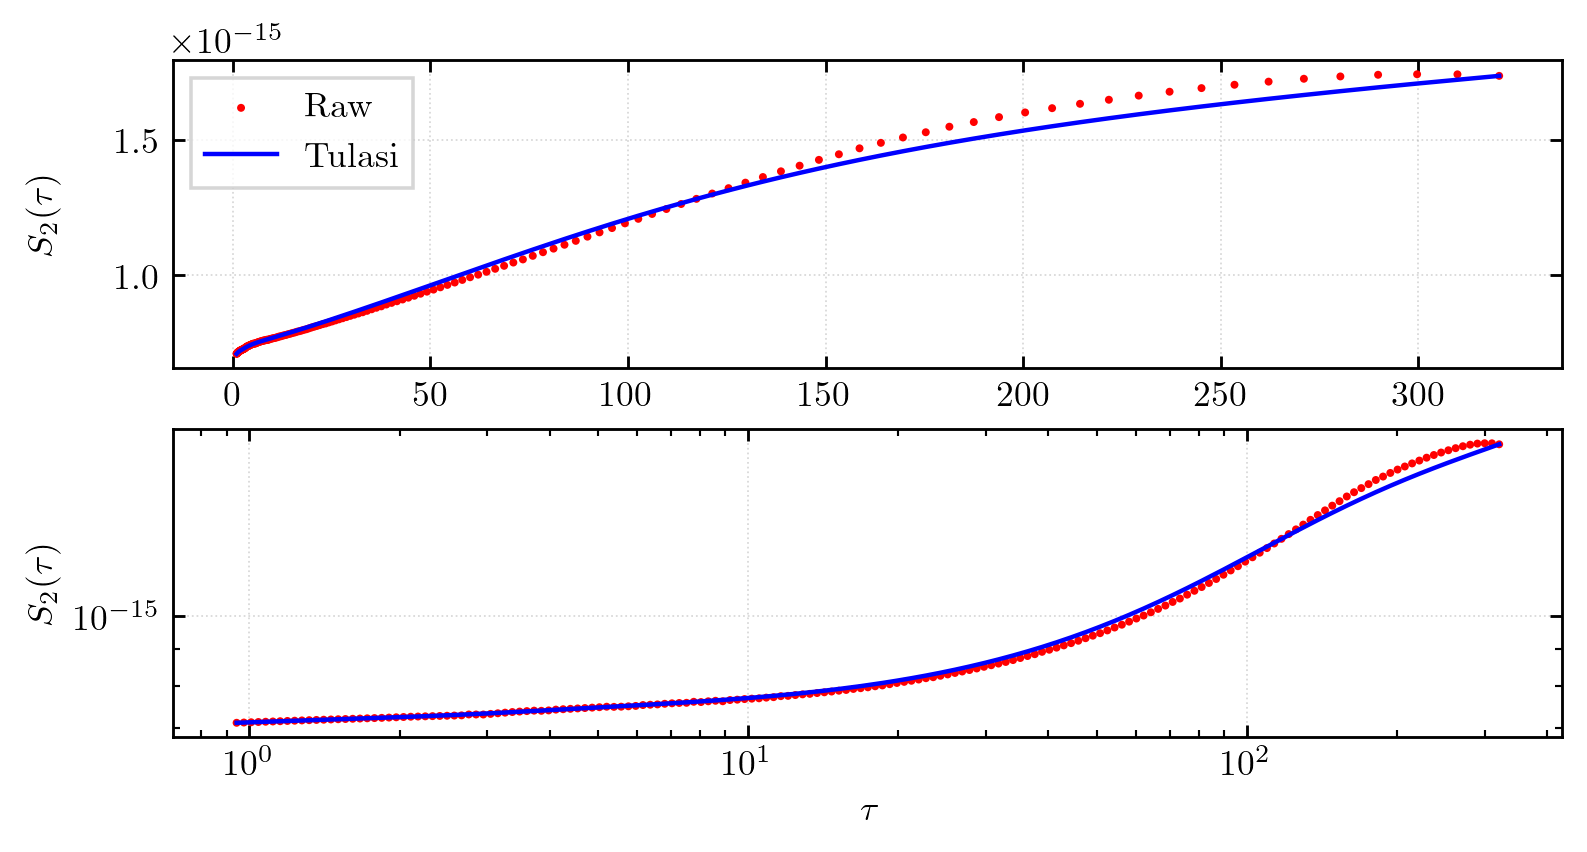

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(3.5*2., 3.5), dpi=256)

l_pr = l_p[np.isfinite(sf2_p)]
sf2_pr = sf2_p[np.isfinite(sf2_p)]

sf2_pi = strfn_spectra.interpolate(l_pr, sf2_pr, l_p)

for axx in ax:
    axx.scatter(l_p, sf2_pi, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='none', label='Raw')

sf2_s1 = np.exp(SmoothySpec(np.log(sf2_pi)))
NN = 8
for _i in range(NN):
    sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), start=_i*N//NN))
for _ in range(5):
    sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), end=12))
#for _ in range(50):
#   sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), start=np.min(np.where(l_p > 1./BREAK)[0])))
for axx in ax:
    axx.plot(l_p, sf2_s1, color='blue', linewidth=1.25, linestyle='-', label='Tulasi')


for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    axx.set_ylabel(r'$S_2(\tau)$')
    axx.set_xlabel(r'$\tau$')

ax[0].legend(fancybox=False)
ax[1].set_yscale('log')
ax[1].set_xscale('log')

fig.align_ylabels()

/tmp/ipykernel_101226/2569803139.py:23: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(sfek_p), np.log(lk_p))


2*sqrt(pi)*gamma(3/2 - alpha/2)/(2**alpha*gamma(alpha/2))

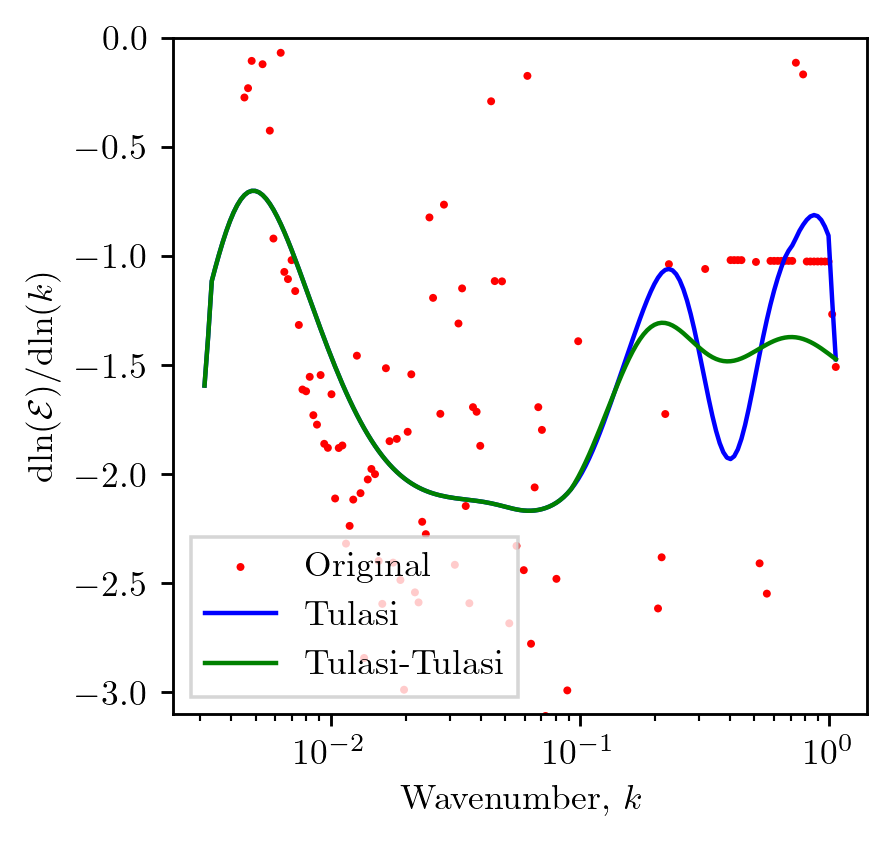

In [13]:

def omni_spectrum(ell, sf2, phys_dims, grid_dims, a=1., b=1.):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    return kk[::-1], fek[::-1]

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lk_o, sfek_o = omni_spectrum(l_p, sf2_pi, phys_dims, grid_dims)

smooth_specs = [sf2_p, sf2_pi, sf2_s1]
e_specs = []
e_alphas = []
for sp in smooth_specs:
    lk_p, sfek_p = omni_spectrum(l_p, sp, phys_dims, grid_dims)
    est_alpha = np.gradient(np.log(sfek_p), np.log(lk_p))
    #est_alpha = (lk_p / sfek_p) * np.gradient(sp, lk_p)
    e_specs.append((lk_p, sfek_p))
    e_alphas.append((est_alpha))

#ax.plot(e_specs[0][0], e_alphas[0], linewidth=1., linestyle=':', color='red', label='Original')
ax.scatter(e_specs[1][0], e_alphas[1], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='none', label='Original')
ax.plot(e_specs[2][0], e_alphas[2], color='blue', linewidth=1.25, linestyle='-', label='Tulasi')

import sympy as sp

sp_alpha = sp.symbols('alpha', positive=True, real=True)
spec_bias = sp.S(2)*sp.S(2)**(-sp_alpha) * sp.sqrt(sp.pi) * (sp.gamma((sp.S(3) - sp_alpha) / sp.S(2))/sp.gamma(sp_alpha/sp.S(2)))
display(spec_bias)


test = SmoothySpec(e_alphas[2], start=np.min(np.where(e_specs[2][0] > 9e-2)))
for _ in range(5):
    test = SmoothySpec(test, start=np.min(np.where(e_specs[2][0] > 9e-2)))
ax.plot(e_specs[2][0], test, color='green', linewidth=1.25, linestyle='-', label='Tulasi-Tulasi')

bias_factor = []
for _a in test:
    est_alpha[est_alpha > -1.1] = -1.1
    est_alpha[est_alpha < -2.9] = -2.9
    bias_factor.append(np.float64(spec_bias.subs({sp_alpha: -_a}).evalf()))
bias_factor = np.array(bias_factor)

#ax.plot(lk_p, est_alpha, linewidth=1., linestyle=(0,(5,5)), color='gray')

ax.set_xscale('log')
ax.set_ylim((-3.1, 0.))

ax.set_ylabel(r'd$\ln(\mathcal{E})/$d$\ln(k)$')
ax.set_xlabel(r'Wavenumber, $k$')

ax.legend(fancybox=False, loc='lower left')


In [14]:

kD, fekD = per_spectra.modal_spectrum(fluct_smooth, fluct_smooth, phys_dims=phys_dims)
kp, fekp, _ = spectra_base.spectrum_integrate(kD, fekD, 'omni', lenn=phys_dims)


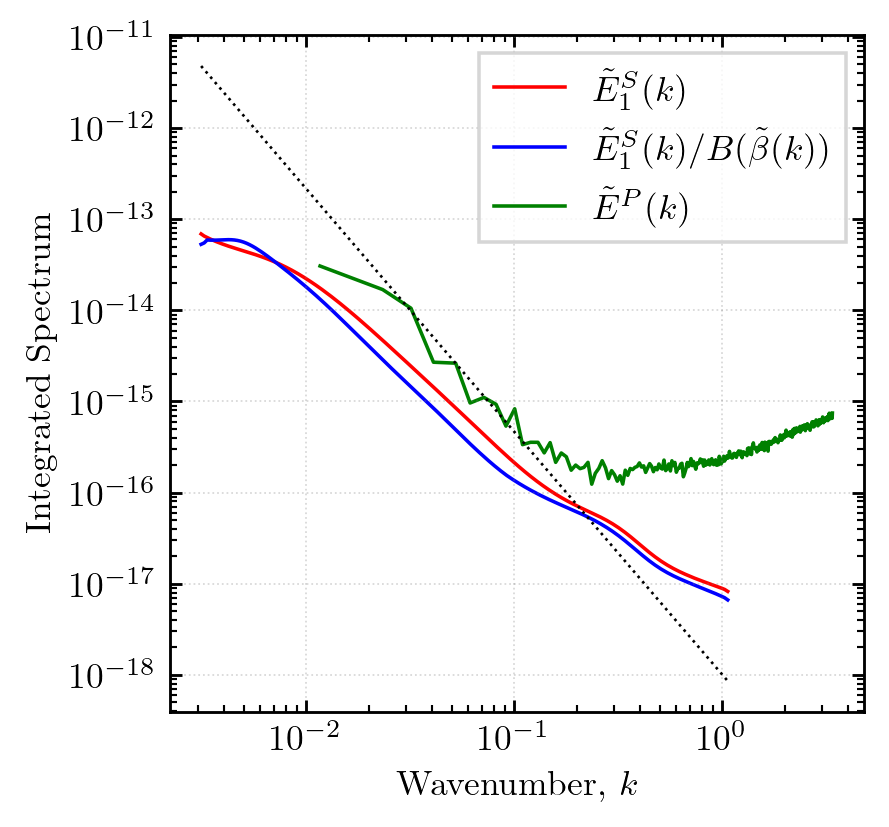

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)


#sfek_pE = spectra_base.translate_spectrum(lk_p, sfek_p, np.gradient(lk_p), 'omni', 'modal', grid_dims, phys_dims, orig_dim=2, bin_center=True)
#sfek_pbE = spectra_base.translate_spectrum(lk_p, sfek_p/bias_factor, np.gradient(lk_p), 'omni', 'modal', grid_dims, phys_dims, orig_dim=2, bin_center=True,)

ax.loglog(lk_p, sfek_p, linewidth=1., color='red', zorder=1, label=r'$\tilde{E}^S_1(k)$')
ax.loglog(lk_p, sfek_p/bias_factor, linewidth=1., color='blue', zorder=1, label=r'$\tilde{E}^S_1(k)/B(\tilde{\beta}(k))$')

ax.loglog(kp, fekp / 1e5, linewidth=1., color='green', zorder=1, label=r'$\tilde{E}^{P}(k)$')





# import pandas as pd
# churazov_chandra_data = pd.read_csv('/home/m/Documents/science_codes/Data/churazov_chandra_pspec_data.txt', delimiter='  ')
# dk2 = (2.*np.pi/L)**2
# #dk2 = 1./L[0]**2
# dk2churazov = (2.*np.pi/Lchurazov.value)**2
# ax.scatter(churazov_chandra_data['k']*2.*np.pi, churazov_chandra_data['pspec'] / Lchurazov.value**D, label='(Scaled) Churazov et al. 2012', marker='.', color='black', zorder=0)

ax.plot(lk_p, 1e-18 * lk_p**(-8./3.), color='black', linestyle=':', linewidth=0.75)

#ax.set_ylim((1e-6, 2e0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.legend(frameon=True, fancybox=False)

ax.set_ylabel(r'Integrated Spectrum')
ax.set_xlabel(r'Wavenumber, $k$')

fig.savefig('plots/realistic_example_2d.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/realistic_example_2d.png', transparent=True, bbox_inches='tight', pad_inches=0)
